![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)

# Laboratory 4. Process Design Kit (PDK) and Layout

In [3]:
import gdsfactory as gf

## 1. Technology

We will work with the **demo UPVfab PDK**. (There are some other open-source PDKs, in other technologies, feel free to search if interested)

In [4]:
from upvfab.sin300.cband import PDK, cells

Let's view the layer distribution of this PDK. In our case, for the passive devices we will only use the **Layer 1**. 

2026-06-11 00:04:45.990 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


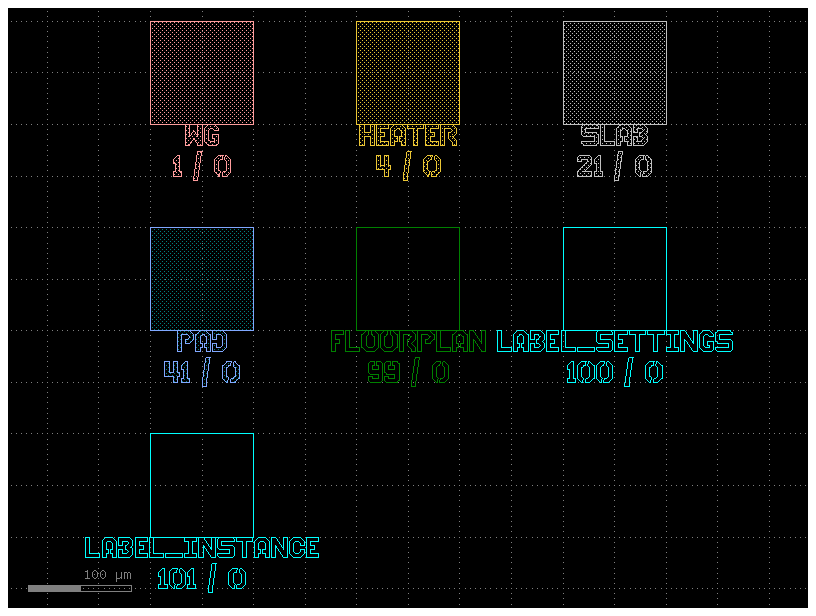

In [13]:
LAYER_VIEWS = PDK.layer_views
c = LAYER_VIEWS.preview_layerset()
c.show()
c.plot()


The new versions of GDS Factory allow to view the Layer Stack also (3D view of the fabrication flow). The following code allows to generate and view the Layer Stack of the generic PDK. Reference: https://www.degruyter.com/document/doi/10.1515/nanoph-2013-0034/html

The layers and the thicknesses have been defined previously on the PDK, so it is possible to view in 3D some of the components in the PDK. 

See the [Reference Manual](https://gdsfactory.github.io/gdsfactory/components.html) and read the list of the available components.

Here are some examples of the 3D views of this photonic components

2026-06-11 00:04:50.053 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


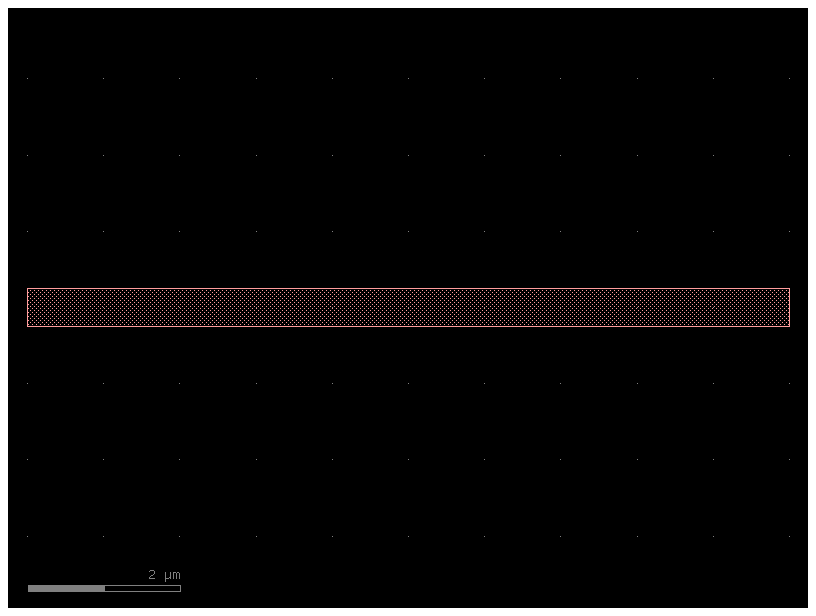

In [14]:
xs = gf.cross_section.strip(width=0.5, layer = 'WG')

c = gf.components.straight(length=10, cross_section=xs)  #Deep 
c.plot() # To view the component on Notebook
c.show() # To view on KLayout
scene = c.to_3d()
scene.show()


2026-06-11 00:04:53.346 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server
2026-06-11 00:04:53.366 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


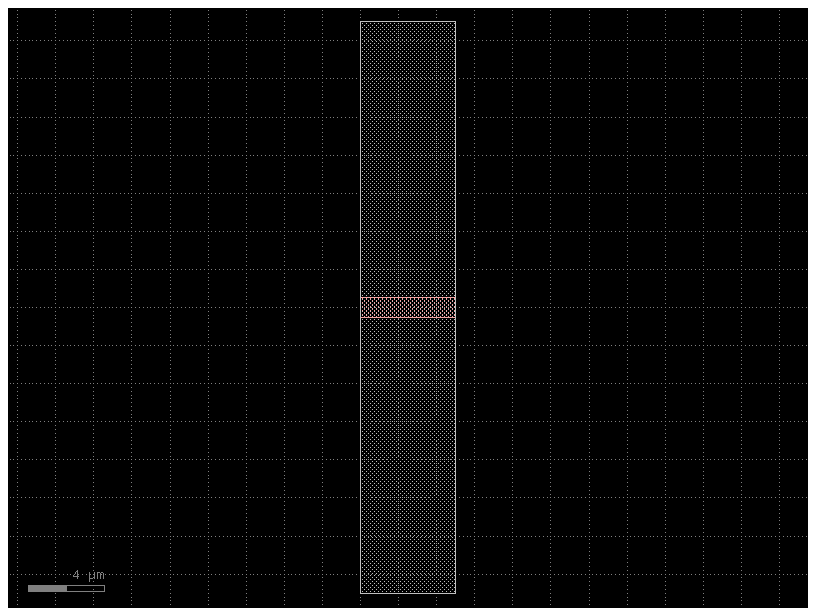

In [15]:
c = gf.components.straight(length=5, cross_section='rib') #Shallow
c.plot()
c.show()

scene = c.to_3d()
c.show()
scene.show()

In [16]:
c = cells.taper_strip_to_ridge(length=10) #Taper
c.show()

scene = c.to_3d()
scene.show()

2026-06-11 00:04:56.586 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


2026-06-11 00:04:58.765 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


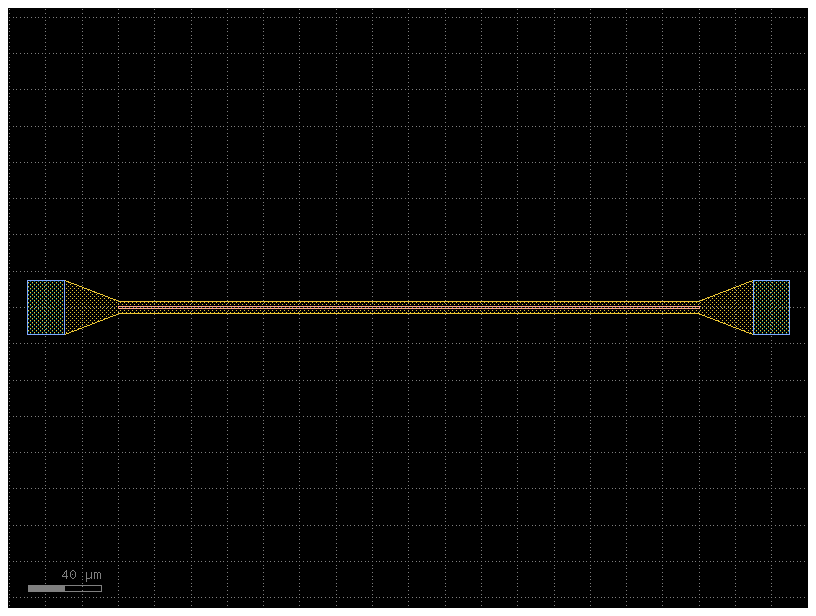

In [17]:
c = cells.straight_heater_metal()

#c.pprint_ports()

c.plot()
c.show()
#c.draw_ports()

scene = c.to_3d()
scene.show()

- Use your design results from Lab2 and Lab3 to create **layout** instances of your designed components: DCs, MMIs, MZIs & Ring Resonators. 

## 1.1 DC

Diseño manual

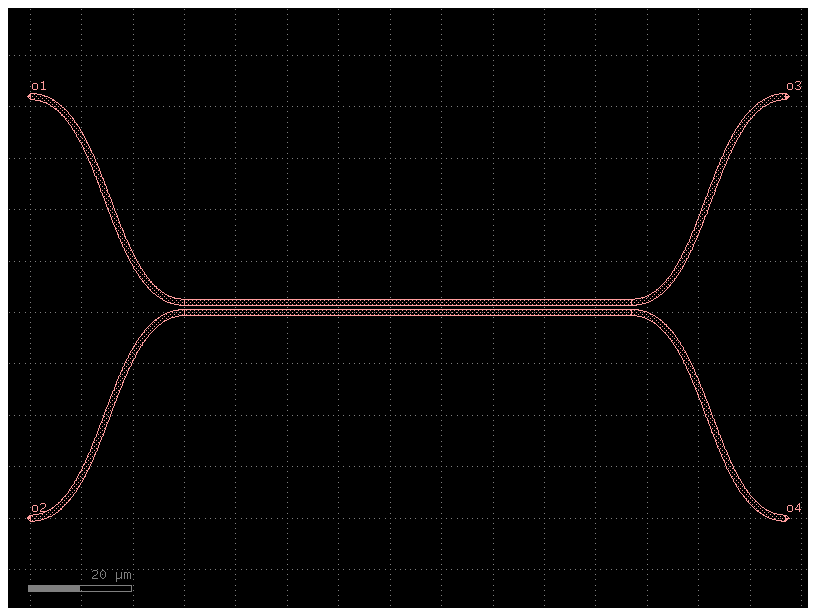

In [8]:
# Creamos el componente 
c = gf.Component()

# Parametros
length: float = 86.982 
gap: float = 0.8     
dx: float = 30.0     
dy: float = 40.0
width: float = 1.2

# Definimos la sección transversal tipo Strip con tu ancho de 1.2 micras en la capa 'WG'
xs = gf.cross_section.strip(width=1.2, layer="WG")

# Región de acoplo
region_central = c.add_ref(gf.components.coupler_straight( length=length, gap=gap,cross_section=xs))
#izquierda
s_bend_sup_izq = c.add_ref(gf.components.bend_s(size=(dx, dy), cross_section=xs))
s_bend_sup_izq.connect("o1", region_central.ports["o1"])
s_bend_inf_izq = c.add_ref(gf.components.bend_s( size=(dx, dy), cross_section=xs)).mirror()
s_bend_inf_izq.connect("o1", region_central.ports["o2"])
#derecha
s_bend_sup_der = c.add_ref( gf.components.bend_s(size=(dx, dy), cross_section=xs))
s_bend_sup_der.connect("o1", region_central.ports["o3"])
s_bend_inf_der = c.add_ref(gf.components.bend_s(size=(dx, dy), cross_section=xs)).mirror()
s_bend_inf_der.connect("o1", region_central.ports["o4"])

# Puertos
c.add_port(name="o1", port=s_bend_inf_izq.ports["o2"]) # Entrada Inferior Izquierda
c.add_port(name="o2", port=s_bend_sup_izq.ports["o2"]) # Entrada Superior Izquierda
c.add_port(name="o3", port=s_bend_sup_der.ports["o2"]) # Salida Superior Derecha
c.add_port(name="o4", port=s_bend_inf_der.ports["o2"]) # Salida Inferior Derecha

c.draw_ports()

c.plot()



Diseño automático

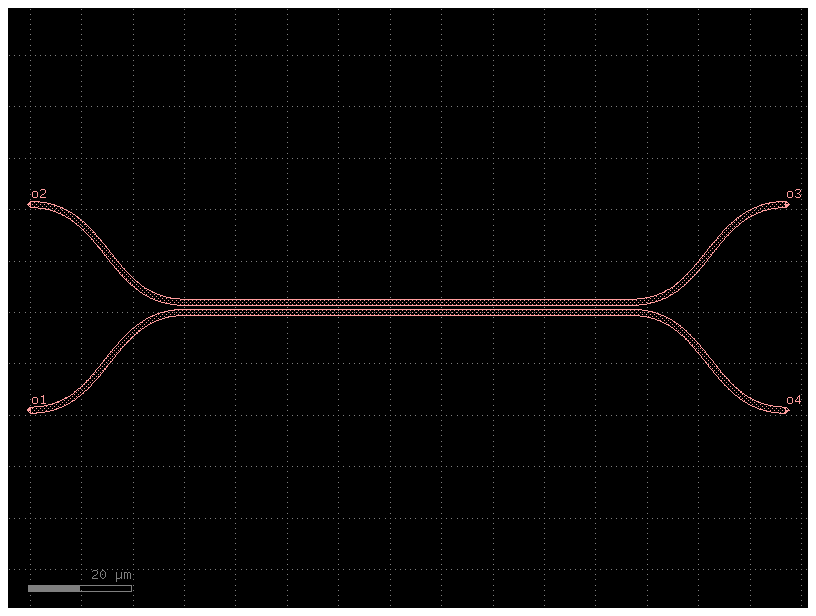

In [9]:

# Activamos el PDK de la UPV
PDK.activate()

# Definimos la sección transversal (Cross-Section) tipo strip con tu ancho de 1.2 um
# y forzamos a que pinte en la capa 'WG' de tu PDK
xs_personalizado = gf.cross_section.strip(width=1.2, layer="WG")

# Creamos el componente con tus dimensiones exactas del Lab 2
c = gf.components.coupler(
    length=86.982,           # Tu Lc óptima
    gap=0.8,                # Tu Gap óptimo
    dy=40.0,                # Distancia vertical para separar las salidas
    dx=30.0,                # Distancia horizontal para la curva S
    cross_section=xs_personalizado
)

# Dibujamos y mostramos el layout
c.draw_ports()
c.plot()

## 1.2 MMI

Diseño automátco

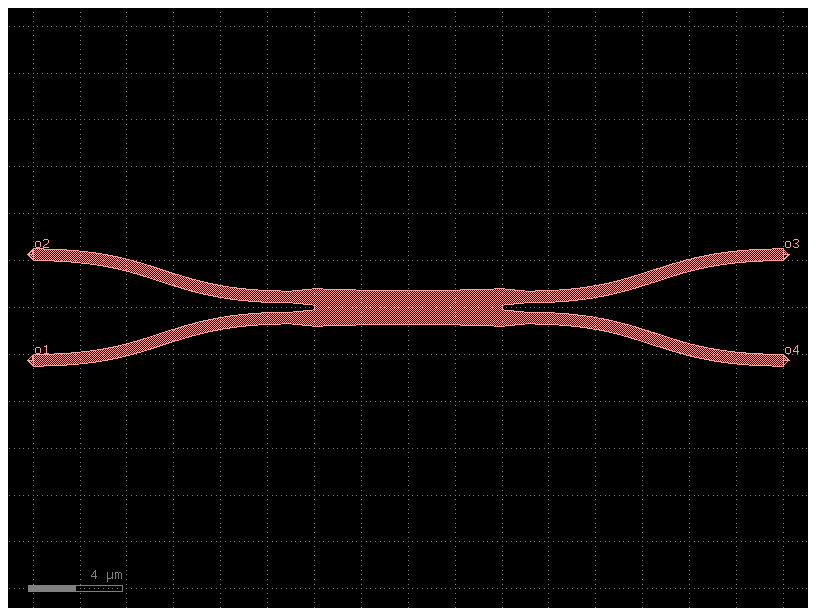

In [10]:
import gdsfactory as gf

gf.gpdk.PDK.activate()

c = gf.components.mmi2x2_with_sbend(with_sbend=True, cross_section='strip').copy()
c.draw_ports()
c.plot()

Diseño manual (MMI guias rectas)

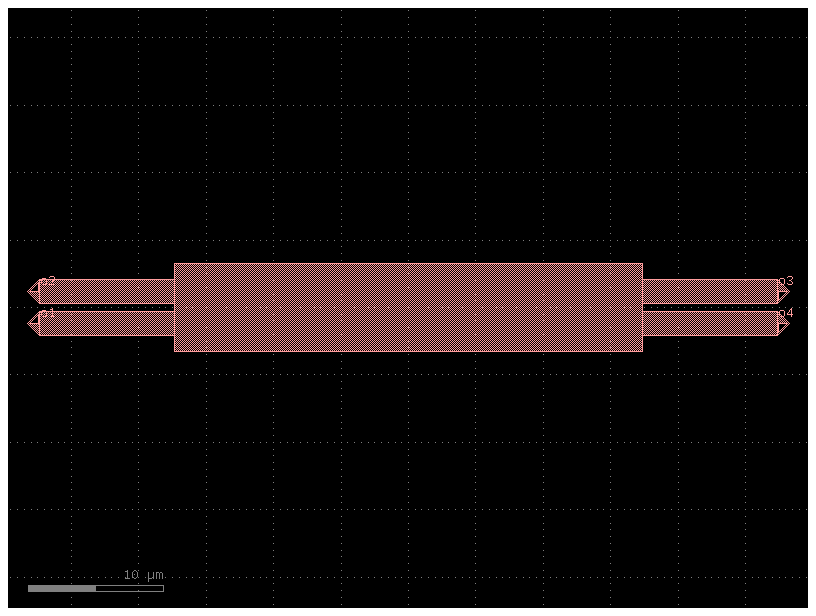

In [11]:

gf.clear_cache()

c = gf.Component()
# Parametros
W_MMI   = float(6.6)      # Ancho del bloque multimodo (mmi_Width del Lab2)
L_MMI   = float(34.718)   # L_MMI + dL_MMI = 34.518 + 0.2 del Lab2
W_wg    = float(1.8)      # Ancho guías de acceso (IO wg width del Lab2)1+0.8
L_wg   = float(10.0)    
dy      = float(0.1)      # Offset de posición de los puertos 

# Posiciones de los puertos según tu fórmula del Lab2:
pos_inf = W_MMI * (-1/6) + (-dy)   # Puerto inferior
pos_sup = W_MMI * ( 1/6) + ( dy)   # Puerto superior

# Bloque central
mmi_core = c.add_ref(gf.components.rectangle(size=(L_MMI, W_MMI), layer="WG"))
# Centrar el bloque en el origen
mmi_core.dmove((-L_MMI / 2, -W_MMI / 2))

# Guias de acceso
xs = gf.cross_section.strip(width = W_wg, layer = 'WG')
wg = gf.components.straight(length = L_wg, cross_section=xs)

# Entrada superior izquierda (o2)
t_o2 = c.add_ref(wg)
t_o2.drotate(180)
t_o2.dmove((-L_MMI / 2, pos_sup))

# Entrada inferior izquierda (o1)
t_o1 = c.add_ref(wg)
t_o1.drotate(180)
t_o1.dmove((-L_MMI / 2, pos_inf))

# Salida superior derecha (o3)
t_o3 = c.add_ref(wg)
t_o3.dmove((L_MMI / 2, pos_sup))

# Salida inferior derecha (o4)
t_o4 = c.add_ref(wg)
t_o4.dmove((L_MMI / 2, pos_inf))

# Puertos externos 
c.add_port(name="o1", center=(-L_MMI/2 - L_wg, pos_inf),width=W_wg, orientation=180, layer="WG")
c.add_port( name="o2", center=(-L_MMI/2 - L_wg, pos_sup),width=W_wg, orientation=180, layer="WG")
c.add_port(name="o3", center=( L_MMI/2 + L_wg, pos_sup),width=W_wg, orientation=0,   layer="WG")
c.add_port(name="o4", center=( L_MMI/2 + L_wg, pos_inf),width=W_wg, orientation=0,   layer="WG")

c.draw_ports()

c.plot()


Diseño manual (MMI guias curvas)

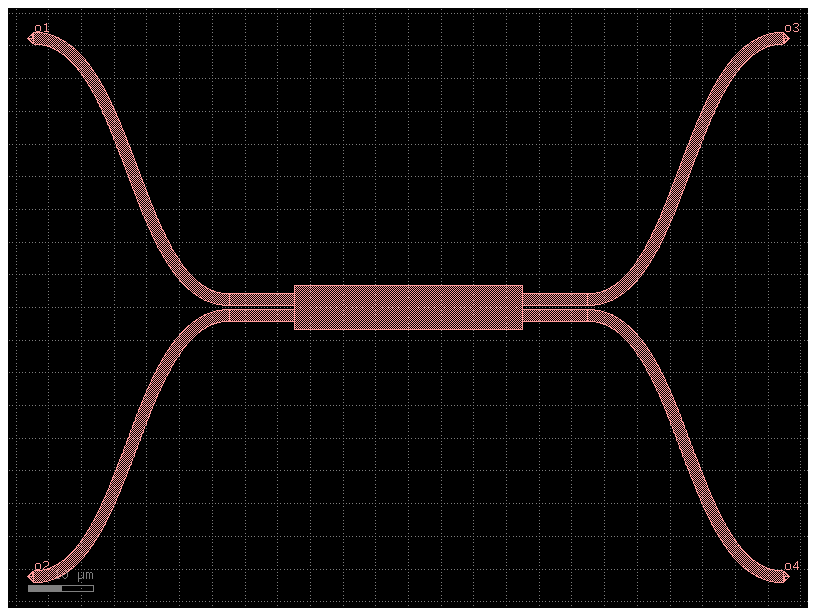

In [12]:

gf.clear_cache()

c = gf.Component()
# Parametros
W_MMI   = float(6.6)      # Ancho del bloque multimodo (mmi_Width del Lab2)
L_MMI   = float(34.718)   # L_MMI + dL_MMI = 34.518 + 0.2 del Lab2
W_wg    = float(1.8)      # Ancho guías de acceso (IO wg width del Lab2)1+0.8
L_wg   = float(10.0)    
dy      = float(0.1)      # Offset de posición de los puertos 
dx_bend = float(30.0)
dy_bend = float(40.0)

# Posiciones de los puertos:
pos_inf = W_MMI * (-1/6) + (-dy)   # Puerto inferior
pos_sup = W_MMI * ( 1/6) + ( dy)   # Puerto superior

# Bloque central 
mmi_core = c.add_ref(
    gf.components.rectangle(size=(L_MMI, W_MMI), layer="WG"))
# Centrar el bloque en el origen
mmi_core.dmove((-L_MMI / 2, -W_MMI / 2))

# Guias de acceso
xs = gf.cross_section.strip(width = W_wg, layer = 'WG')
wg = gf.components.straight(length = L_wg, cross_section=xs)

# Entrada superior izquierda (o2)
t_o2 = c.add_ref(wg)
t_o2.drotate(180)
t_o2.dmove((-L_MMI / 2, pos_sup))

# Entrada inferior izquierda (o1)
t_o1 = c.add_ref(wg)
t_o1.drotate(180)
t_o1.dmove((-L_MMI / 2, pos_inf))

# Salida superior derecha (o3)
t_o3 = c.add_ref(wg)
t_o3.dmove((L_MMI / 2, pos_sup))

# Salida inferior derecha (o4)
t_o4 = c.add_ref(wg)
t_o4.dmove((L_MMI / 2, pos_inf))


#  BEND_S conectados al final de cada guía 
# Izquierda superior
bs_sup_izq = c.add_ref(gf.components.bend_s(size=(dx_bend, dy_bend), cross_section=xs))
bs_sup_izq.connect("o1", t_o1.ports["o2"])

# Izquierda inferior
bs_inf_izq = c.add_ref(gf.components.bend_s(size=(dx_bend, dy_bend), cross_section=xs)).mirror()
bs_inf_izq.connect("o1", t_o2.ports["o2"])

# Derecha superior
bs_sup_der = c.add_ref(gf.components.bend_s(size=(dx_bend, dy_bend), cross_section=xs))
bs_sup_der.connect("o1", t_o3.ports["o2"])

# Derecha inferior
bs_inf_der = c.add_ref(gf.components.bend_s(size=(dx_bend, dy_bend), cross_section=xs)).mirror()
bs_inf_der.connect("o1", t_o4.ports["o2"])

# Puertos al final de los bend_s 
c.add_port(name="o1", port=bs_inf_izq.ports["o2"])  # Entrada inferior izq
c.add_port(name="o2", port=bs_sup_izq.ports["o2"])  # Entrada superior izq
c.add_port(name="o3", port=bs_sup_der.ports["o2"])  # Salida superior der
c.add_port(name="o4", port=bs_inf_der.ports["o2"])  # Salida inferior der
c.draw_ports()

c.plot()



## 1.3 Ring resonator

Diseño automático

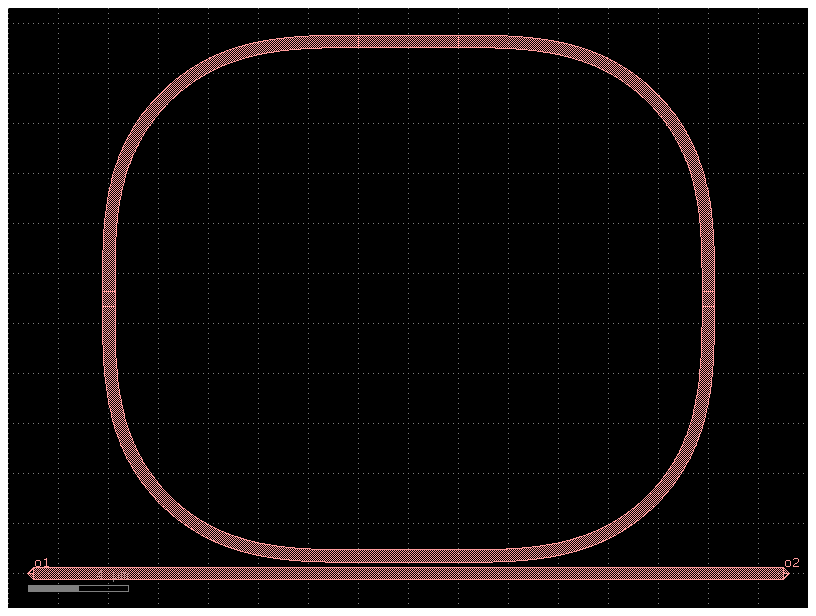

In [13]:
import gdsfactory as gf

gf.gpdk.PDK.activate()

c = gf.components.ring_single(gap=0.2, length_x=4, length_y=0.6, bend='bend_euler', straight='straight', coupler_ring='coupler_ring', cross_section='strip').copy()
c.draw_ports()
c.plot()

Diseño Manual

/Users/claudia/cifoin-lab4-pascual/.venv/lib/python3.12/site-packages/cachetools/_cached.py:185: UserWarning: bend_euler angle should be 90 or 180. Got -90. Use bend_euler_all_angle instead.
  v = func(*args, **kwargs)
/Users/claudia/cifoin-lab4-pascual/.venv/lib/python3.12/site-packages/gdsfactory/components/bends/bend_euler.py:110: UserWarning: {'width': 1.8} ignored for cross_section 'xs_8c587ccf'
  x = gf.get_cross_section(cross_section, width=width or x.width)


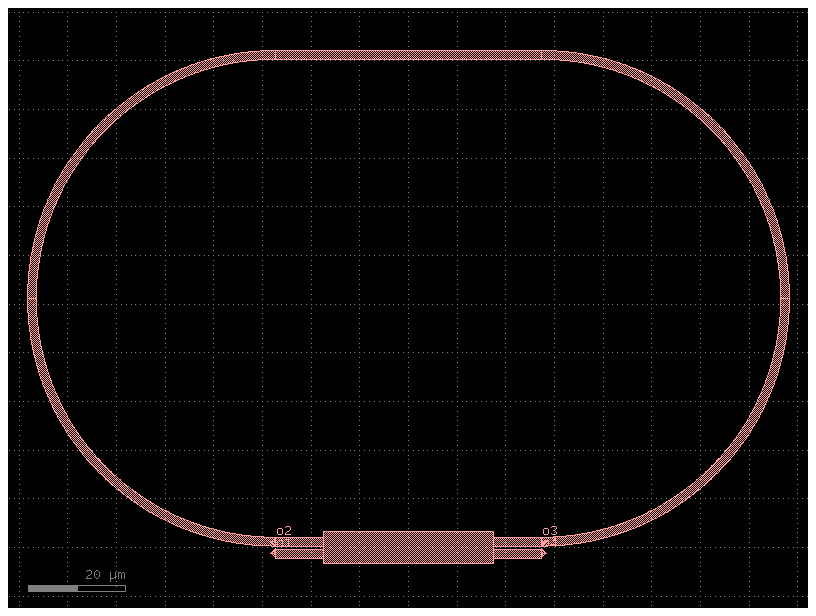

In [14]:
gf.clear_cache()

c  = gf.Component()
#parametros
W_MMI   = float(6.6)
L_MMI   = float(34.718)
W_wg    = float(1.8)
L_wg    = float(10.0)
dy      = float(0.1)
radio   = float(50.0)
xs = gf.cross_section.strip(width=W_wg, layer="WG")

# MMI central   
#----------------------------------
# Posiciones de los puertos según tu fórmula del Lab2:
pos_inf = W_MMI * (-1/6) + (-dy)   # Puerto inferior
pos_sup = W_MMI * ( 1/6) + ( dy)   # Puerto superior

# Bloque central
mmi_core = c.add_ref(gf.components.rectangle(size=(L_MMI, W_MMI), layer="WG"))
# Centrar el bloque en el origen
mmi_core.dmove((-L_MMI / 2, -W_MMI / 2))

# Guias de acceso
wg = gf.components.straight(length = L_wg, cross_section=xs)

# Entrada superior izquierda (o2)
t_o2 = c.add_ref(wg)
t_o2.drotate(180)
t_o2.dmove((-L_MMI / 2, pos_sup))

# Entrada inferior izquierda (o1)
t_o1 = c.add_ref(wg)
t_o1.drotate(180)
t_o1.dmove((-L_MMI / 2, pos_inf))

# Salida superior derecha (o3)
t_o3 = c.add_ref(wg)
t_o3.dmove((L_MMI / 2, pos_sup))

# Salida inferior derecha (o4)
t_o4 = c.add_ref(wg)
t_o4.dmove((L_MMI / 2, pos_inf))

#----------------------------------
# Lado derecho
bend_der_1 = c.add_ref(gf.components.bend_circular(angle=90, radius=radio, cross_section=xs))
bend_der_1.connect("o1", t_o3.ports["o2"])

bend_der_2 = c.add_ref(gf.components.bend_circular(angle=90, radius=radio, cross_section=xs))
bend_der_2.connect("o1", bend_der_1.ports["o2"])

# Lado izquierdo
bend_izq_1 = c.add_ref(gf.components.bend_circular(angle=-90, radius=radio, cross_section=xs))
bend_izq_1.connect("o1", t_o2.ports["o2"])

bend_izq_2 = c.add_ref(gf.components.bend_circular(angle=-90, radius=radio, cross_section=xs))
bend_izq_2.connect("o1", bend_izq_1.ports["o2"])

# Separación entre o3 y o2 
sep_puertos = abs(t_o2.ports["o2"].dy - t_o3.ports["o2"].dy) 

# Recto superior
recto = c.add_ref(gf.components.straight(length=sep_puertos , cross_section=xs))
recto.connect("o1", bend_der_2.ports["o2"])
# Si no coincide exactamente usar route_single:
gf.routing.route_single(component=c,port1=recto.ports["o2"],port2=bend_izq_2.ports["o2"],cross_section=xs)

# Puertos externos
c.add_port(name="o1", port=t_o1.ports["o2"])
c.add_port(name="o2", port=t_o2.ports["o2"])
c.add_port(name="o3", port=t_o3.ports["o2"])
c.add_port(name="o4", port=t_o4.ports["o2"])

c.draw_ports()
c.plot()

## 1.4 MZI

2026-06-09 23:05:42.643 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


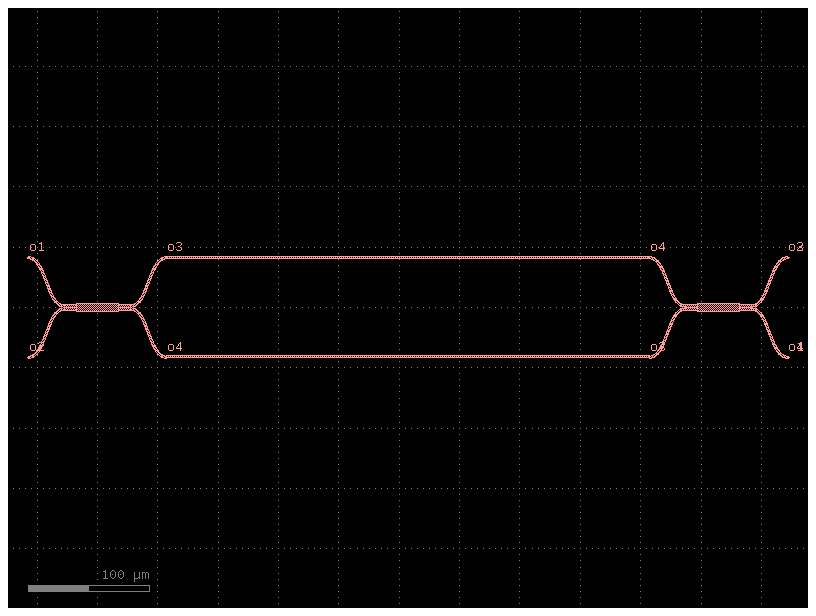

In [50]:
gf.clear_cache()

@gf.cell
def mzi(
    delta_length= 0.0, 
    L_brazo=400.0,
): 
    c  = gf.Component()
    xs = gf.cross_section.strip(width=1.8, layer="WG")

    # ── 1. SPLITTER (DC izquierdo) ────────────────────────────────────────
    splitter = c.add_ref(mmi2x2_bend())

    # ── 2. BRAZOS ─────────────────────────────────────────────────────────
    # El brazo superior lleva la longitud extra (delta_length)
    # El brazo inferior es la referencia
    brazo_sup = c.add_ref(gf.components.straight(length=L_brazo + delta_length, cross_section=xs)) #length=L_brazo + delta_length
    brazo_inf = c.add_ref(gf.components.straight(length=L_brazo, cross_section=xs))

    # Conectar brazos a las salidas del splitter
    brazo_sup.connect("o1", splitter.ports["o3"])  # Sale por o3 (superior der)
    brazo_inf.connect("o1", splitter.ports["o4"])  # Sale por o4 (inferior der)

    # ── 3. COMBINER (DC derecho) ──────────────────────────────────────────
    combiner = c.add_ref(mmi2x2_bend())
    combiner.connect("o3", brazo_inf.ports["o2"])  # o4 recibe brazo inferior
    
    # ── 4. PUERTOS EXTERNOS DEL MZI ───────────────────────────────────────
    c.add_port(name="o1", port=splitter.ports["o1"])   # Entrada inferior izq
    c.add_port(name="o2", port=splitter.ports["o2"])   # Entrada superior izq
    c.add_port(name="o3", port=combiner.ports["o2"])   # Salida superior der
    c.add_port(name="o4", port=combiner.ports["o1"])   # Salida inferior der

    c.draw_ports()
    return c

# ── Visualizar ────────────────────────────────────────────────────────────
c = mzi()
c.plot()
c.show()


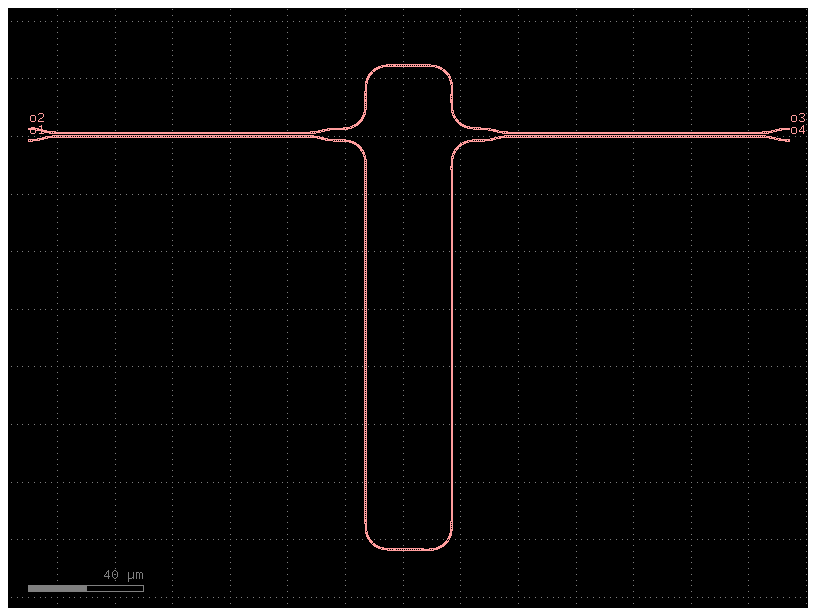

In [16]:
import gdsfactory as gf

gf.gpdk.PDK.activate()
# FSR = 5 nm  → dL ≈ 240 µm 
c = gf.components.mzi_lattice(coupler_lengths=(86.982, 86.982), coupler_gaps=(0.8, 0.8), delta_lengths=(240.0,), mzi='mzi_coupler', splitter='coupler').copy()
c.draw_ports()
c.plot()

## 2. Layout Fundamentals

A cell is a function that returns a Component. In GDS each component must have a unique name. Two components stored in the GDS file cannot have the same name. They need to be references (instances) of the same component.

![GDSFactoryComponents][def]


[def]: https://i.imgur.com/oeuKGsc.png

2026-06-11 00:05:25.288 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


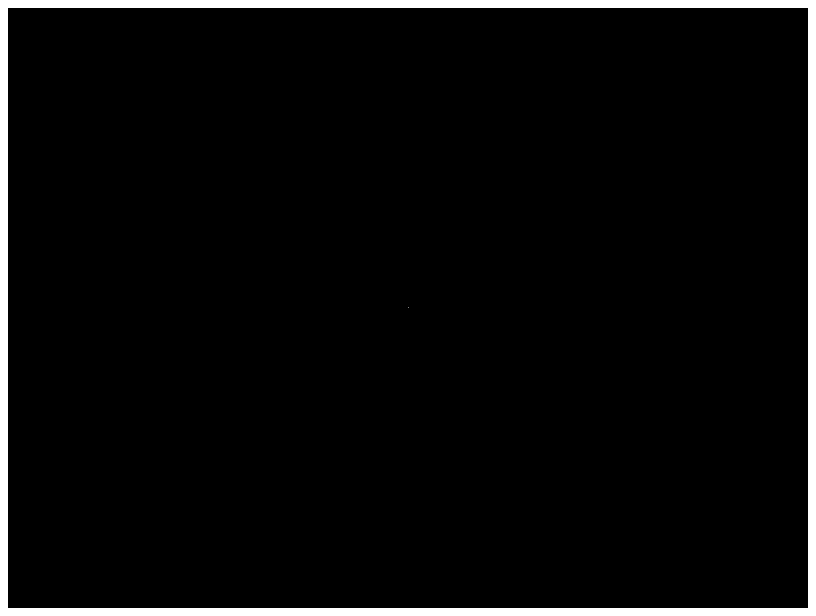

In [18]:
c = gf.Component()
c.plot()
c.show()

Let's build a Component from scratch. A die (chip) for a photonic layout. The PDK or Design Manual should specify the Layer for the bounding box (dicing line). 
We should also consider: 
1. The die dimensions and 
2. The border for dicing 

2026-06-11 00:05:28.536 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


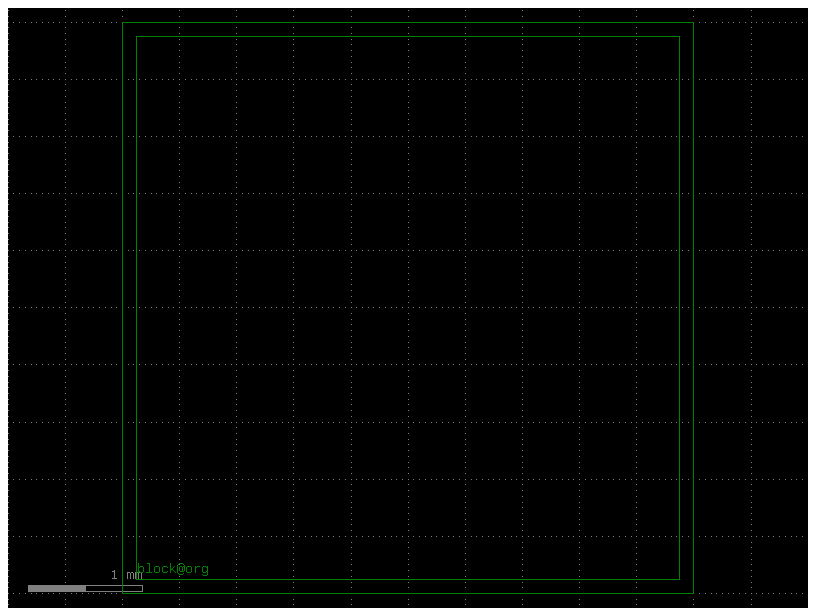

In [19]:
wgw = 0.5
dieL = 5000
dieW = 5000
border = 125
layer_wg = "WG"
layer_box = "FLOORPLAN"

# Die specifications (Chip)
box = gf.Component()

obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
box = gf.boolean(A=obox, B=ibox, operation="A-B", layer="FLOORPLAN")

# Adding ports to a component 
box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)

box.draw_ports()
box.show()
box.plot()

### Mantra: 
Once that we have a working 'new' component, we shall convert it into a Cell. This will allow us to have a hierarchical design

2026-06-11 00:05:31.182 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


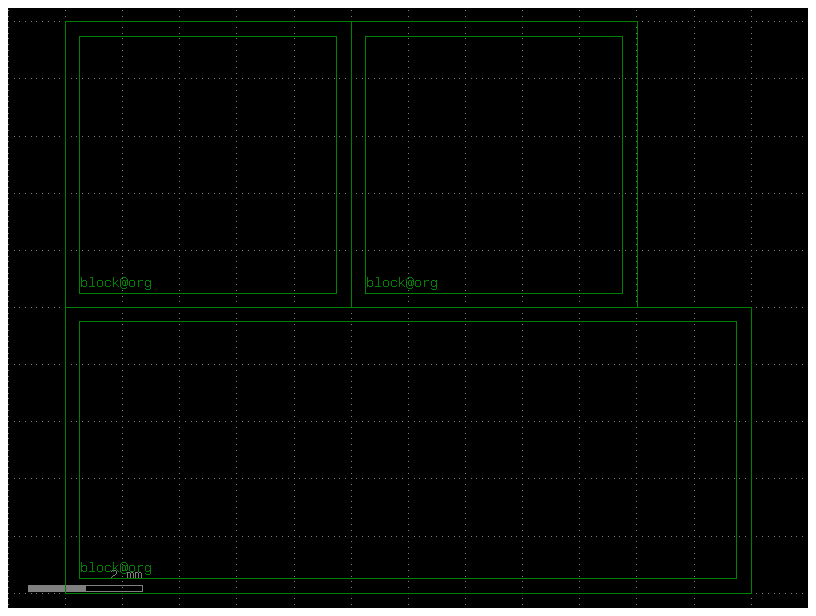

In [20]:
# 1. We define the cell as a function with it's corresponding parameters (and defaults)
gf.clear_cache()

@gf.cell
def die(dieL = 5000, dieW = 5000, border = 250, layer_box = "FLOORPLAN"):
    # Die specifications (Chip)
    box = gf.Component()
    obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
    ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
    box = gf.boolean(A=obox, B=ibox, operation="A-B", layer=layer_box)
    # Adding ports to a component 
    box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)
    box.draw_ports()
    return box

# 2. We instantiate references of each cell. We can also name it individually to avoid problems
wafer = gf.Component()
dieW1 = 5000
dieW2 = 10000

c1 = wafer.add_ref(die(dieW = dieW))
c2 = wafer.add_ref(die(dieW = dieW))
c3 = wafer.add_ref(die(dieW = 12000))

c2.dmovex(dieW1)
c3.dmovey(-5000)
wafer.show()
wafer.plot()


# 2.b 

## DC  cell

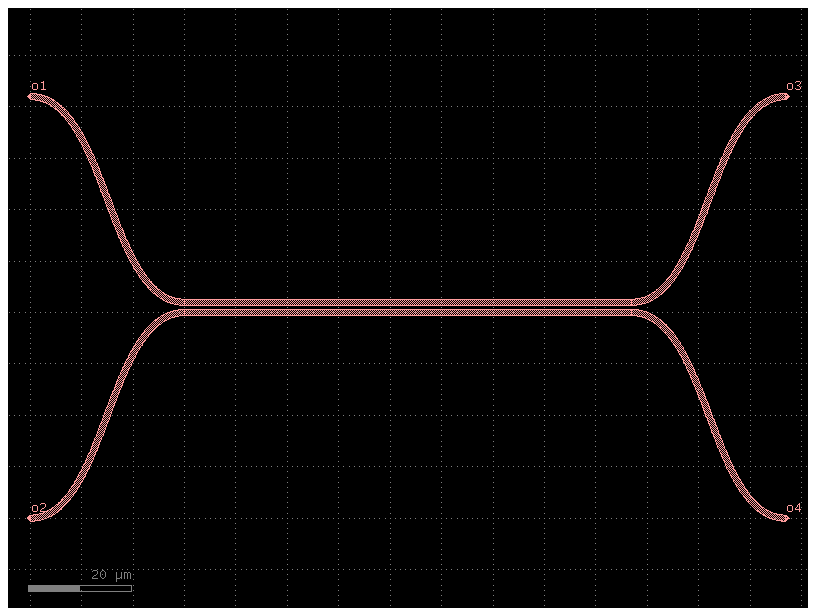

In [20]:

# 1. We define the cell as a function with it's corresponding parameters (and defaults)
gf.clear_cache()

@gf.cell
def dc_2x2(
    length: float = 86.982,  
    gap: float = 0.8,      
    dx: float = 30.0,      
    dy: float = 40.0,
    width: float = 1.2,):

    # Creamos el componente 
    c = gf.Component()
    # Definimos la sección transversal tipo Strip con tu ancho de 1.2 micras en la capa 'WG'
    xs = gf.cross_section.strip(width=1.2, layer="WG")

    region_central = c.add_ref(gf.components.coupler_straight( length=length, gap=gap,cross_section=xs))
    #izquierda
    s_bend_sup_izq = c.add_ref(gf.components.bend_s(size=(dx, dy), cross_section=xs))
    s_bend_sup_izq.connect("o1", region_central.ports["o1"])
    s_bend_inf_izq = c.add_ref(gf.components.bend_s( size=(dx, dy), cross_section=xs)).mirror()
    s_bend_inf_izq.connect("o1", region_central.ports["o2"])
    #derecha
    s_bend_sup_der = c.add_ref( gf.components.bend_s(size=(dx, dy), cross_section=xs))
    s_bend_sup_der.connect("o1", region_central.ports["o3"])
    s_bend_inf_der = c.add_ref(gf.components.bend_s(size=(dx, dy), cross_section=xs)).mirror()
    s_bend_inf_der.connect("o1", region_central.ports["o4"])
    #puertos
    c.add_port(name="o1", port=s_bend_inf_izq.ports["o2"]) # Entrada Inferior Izquierda
    c.add_port(name="o2", port=s_bend_sup_izq.ports["o2"]) # Entrada Superior Izquierda
    c.add_port(name="o3", port=s_bend_sup_der.ports["o2"]) # Salida Superior Derecha
    c.add_port(name="o4", port=s_bend_inf_der.ports["o2"]) # Salida Inferior Derecha

    c.draw_ports()
    return c

# 2. We instantiate references of each cell. We can also name it individually to avoid problems
chip_dc = gf.Component()

dc1 = chip_dc.add_ref(dc_2x2())

chip_dc.plot()



## MMI cell

MMI guias rectas 

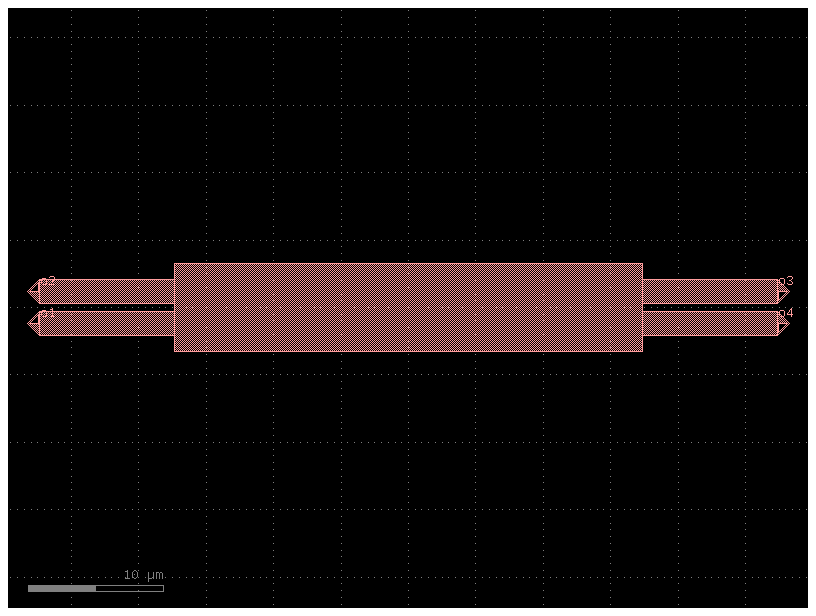

In [81]:
# 1. We define the cell as a function with it's corresponding parameters (and defaults)
gf.clear_cache()

@gf.cell
def mmi2x2(
    W_MMI   = 6.6,      
    L_MMI   = 34.718,   
    W_wg    = 1.8,      
    L_wg   = 10.0,     
    dy      = 0.1,      
):
    c = gf.Component()

    # Posiciones de los puertos:
    pos_inf = W_MMI * (-1/6) + (-dy)   # Puerto inferior
    pos_sup = W_MMI * ( 1/6) + ( dy)   # Puerto superior

    # Bloque central 
    mmi_core = c.add_ref(
        gf.components.rectangle(size=(L_MMI, W_MMI), layer="WG"))
    # Centrar el bloque en el origen
    mmi_core.dmove((-L_MMI / 2, -W_MMI / 2))

    # Guias de acceso
    xs = gf.cross_section.strip(width = W_wg, layer = 'WG')
    wg = gf.components.straight(length = L_wg, cross_section=xs)

    # Entrada superior izquierda (o2)
    t_o2 = c.add_ref(wg)
    t_o2.drotate(180)
    t_o2.dmove((-L_MMI / 2, pos_sup))

    # Entrada inferior izquierda (o1)
    t_o1 = c.add_ref(wg)
    t_o1.drotate(180)
    t_o1.dmove((-L_MMI / 2, pos_inf))

    # Salida superior derecha (o3)
    t_o3 = c.add_ref(wg)
    t_o3.dmove((L_MMI / 2, pos_sup))

    # Salida inferior derecha (o4)
    t_o4 = c.add_ref(wg)
    t_o4.dmove((L_MMI / 2, pos_inf))

    #  Puertos externos
    c.add_port(name="o1", center=(-L_MMI/2 - L_wg, pos_inf),width=W_wg, orientation=180, layer="WG")
    c.add_port( name="o2", center=(-L_MMI/2 - L_wg, pos_sup),width=W_wg, orientation=180, layer="WG")
    c.add_port(name="o3", center=( L_MMI/2 + L_wg, pos_sup),width=W_wg, orientation=0,   layer="WG")
    c.add_port(name="o4", center=( L_MMI/2 + L_wg, pos_inf),width=W_wg, orientation=0,   layer="WG")

    c.draw_ports()
    return c

# 2. We instantiate references of each cell. We can also name it individually to avoid problems
chip_mmi2x2 = gf.Component()

mmi1 = chip_mmi2x2.add_ref(mmi2x2())

chip_mmi2x2.plot()



MMI guias curvas

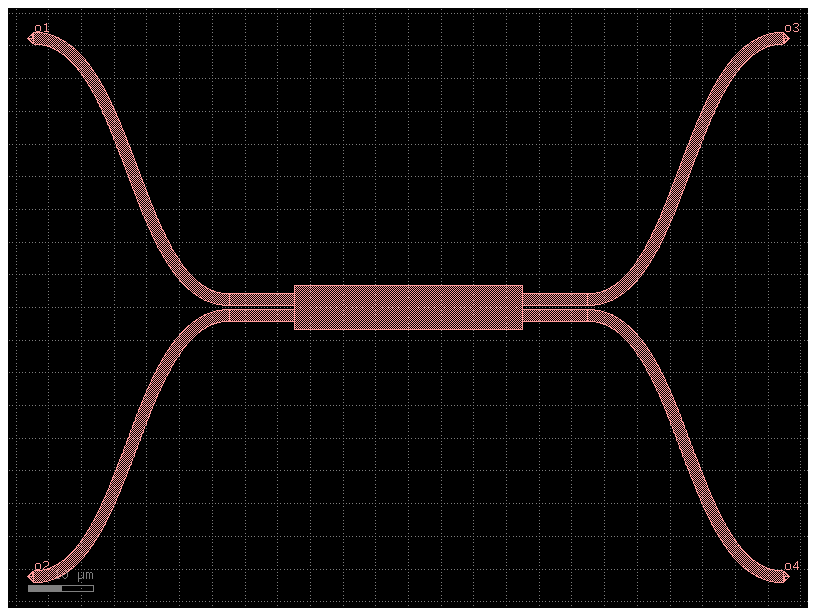

In [82]:
# 1. We define the cell as a function with it's corresponding parameters (and defaults)
gf.clear_cache()

@gf.cell
def mmi2x2_bend(
    W_MMI   = 6.6,      # Ancho del bloque multimodo (mmi_Width del Lab2)
    L_MMI   = 34.718,   # L_MMI + dL_MMI = 34.518 + 0.2 del Lab2
    W_wg    = 1.8,      # Ancho guías de acceso (IO wg width del Lab2) +0.8
    L_wg   = 10.0,     
    dy      = 0.1,      # Offset de posición de los puertos (dy del Lab2)
    dx_bend = 30.0,
    dy_bend = 40.0,
):
    c = gf.Component()

    # Posiciones de los puertos:
    pos_inf = W_MMI * (-1/6) + (-dy)   # Puerto inferior
    pos_sup = W_MMI * ( 1/6) + ( dy)   # Puerto superior

    # Bloque central 
    mmi_core = c.add_ref(
        gf.components.rectangle(size=(L_MMI, W_MMI), layer="WG"))
    # Centrar el bloque en el origen
    mmi_core.dmove((-L_MMI / 2, -W_MMI / 2))

    # Guias de acceso
    xs = gf.cross_section.strip(width = W_wg, layer = 'WG')
    wg = gf.components.straight(length = L_wg, cross_section=xs)

    # Entrada superior izquierda (o2)
    t_o2 = c.add_ref(wg)
    t_o2.drotate(180)
    t_o2.dmove((-L_MMI / 2, pos_sup))

    # Entrada inferior izquierda (o1)
    t_o1 = c.add_ref(wg)
    t_o1.drotate(180)
    t_o1.dmove((-L_MMI / 2, pos_inf))

    # Salida superior derecha (o3)
    t_o3 = c.add_ref(wg)
    t_o3.dmove((L_MMI / 2, pos_sup))

    # Salida inferior derecha (o4)
    t_o4 = c.add_ref(wg)
    t_o4.dmove((L_MMI / 2, pos_inf))


    #  BEND_S conectados al final de cada guía 
    # Izquierda superior
    bs_sup_izq = c.add_ref(gf.components.bend_s(size=(dx_bend, dy_bend), cross_section=xs))
    bs_sup_izq.connect("o1", t_o1.ports["o2"])

    # Izquierda inferior
    bs_inf_izq = c.add_ref(gf.components.bend_s(size=(dx_bend, dy_bend), cross_section=xs)).mirror()
    bs_inf_izq.connect("o1", t_o2.ports["o2"])

    # Derecha superior
    bs_sup_der = c.add_ref(gf.components.bend_s(size=(dx_bend, dy_bend), cross_section=xs))
    bs_sup_der.connect("o1", t_o3.ports["o2"])

    # Derecha inferior
    bs_inf_der = c.add_ref(gf.components.bend_s(size=(dx_bend, dy_bend), cross_section=xs)).mirror()
    bs_inf_der.connect("o1", t_o4.ports["o2"])

    # Puertos al final de los bend_s 
    c.add_port(name="o1", port=bs_inf_izq.ports["o2"])  # Entrada inferior izq
    c.add_port(name="o2", port=bs_sup_izq.ports["o2"])  # Entrada superior izq
    c.add_port(name="o3", port=bs_sup_der.ports["o2"])  # Salida superior der
    c.add_port(name="o4", port=bs_inf_der.ports["o2"])  # Salida inferior der
    c.draw_ports()
    return c

# 2. We instantiate references of each cell. We can also name it individually to avoid problems
chip_mmi2x2_bend = gf.Component()

mmi1 = chip_mmi2x2_bend.add_ref(mmi2x2_bend())

chip_mmi2x2_bend.plot()



## Ring Resonator Cell

/Users/claudia/cifoin-lab4-pascual/.venv/lib/python3.12/site-packages/cachetools/_cached.py:185: UserWarning: bend_euler angle should be 90 or 180. Got -90. Use bend_euler_all_angle instead.
  v = func(*args, **kwargs)
/Users/claudia/cifoin-lab4-pascual/.venv/lib/python3.12/site-packages/gdsfactory/components/bends/bend_euler.py:110: UserWarning: {'width': 1.8} ignored for cross_section 'xs_8c587ccf'
  x = gf.get_cross_section(cross_section, width=width or x.width)


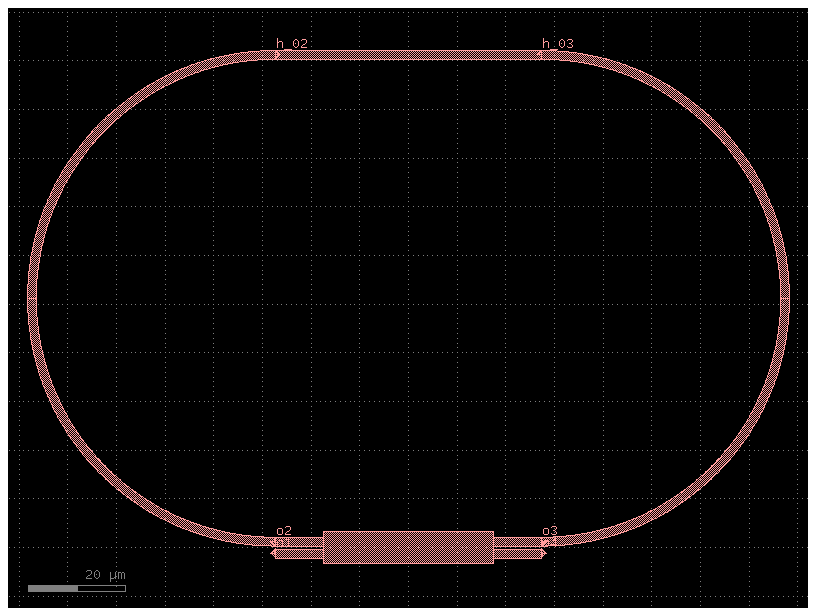

In [157]:
gf.clear_cache()

@gf.cell
def ring_resonator(
    W_MMI   = 6.6,
    L_MMI   = 34.718,
    W_wg    = 1.8,
    L_wg    = 10.0,
    dy      = 0.1,
    radio   = 50.0, 
    L_extra = 0.0,
):
    c  = gf.Component()
    xs = gf.cross_section.strip(width=W_wg, layer="WG")
    
    # MMI central   
    mmi = c.add_ref(mmi2x2(W_MMI=W_MMI, L_MMI=L_MMI, W_wg=W_wg, L_wg=L_wg, dy=dy))


    # Lado derecho
    bend_der_1 = c.add_ref(gf.components.bend_circular(angle=90, radius=radio, cross_section=xs))
    bend_der_1.connect("o1", mmi.ports["o3"])

    bend_der_2 = c.add_ref(gf.components.bend_circular(angle=90, radius=radio, cross_section=xs))
    bend_der_2.connect("o1", bend_der_1.ports["o2"])

    # Lado izquierdo
    bend_izq_1 = c.add_ref(gf.components.bend_circular(angle=-90, radius=radio, cross_section=xs))
    bend_izq_1.connect("o1", mmi.ports["o2"])

    bend_izq_2 = c.add_ref(gf.components.bend_circular(angle=-90, radius=radio, cross_section=xs))
    bend_izq_2.connect("o1", bend_izq_1.ports["o2"])

    # Separación entre o3 y o2 
    sep_puertos = abs(mmi.ports["o2"].dy - mmi.ports["o3"].dy) 

    # Recto superior
    recto = c.add_ref(gf.components.straight(length=sep_puertos , cross_section=xs))
    recto.connect("o1", bend_der_2.ports["o2"])
    # Si no coincide exactamente usar route_single:
    gf.routing.route_single(component=c,port1=recto.ports["o2"],port2=bend_izq_2.ports["o2"],cross_section=xs)

    # Puertos externos
    c.add_port(name="o1", port=mmi.ports["o1"])
    c.add_port(name="o2", port=mmi.ports["o2"])
    c.add_port(name="o3", port=mmi.ports["o3"])
    c.add_port(name="o4", port=mmi.ports["o4"])
    #puertos internos 
    c.add_port(name="h_03", port=bend_der_2.ports["o2"])
    c.add_port(name="h_02", port=bend_izq_2.ports["o2"])
    c.draw_ports()
    return c

# 2. We instantiate references of each cell. We can also name it individually to avoid problems
chip_ring_resonator = gf.Component()

mmi1 = chip_ring_resonator.add_ref(ring_resonator())

chip_ring_resonator.plot()

## MZi cell

Balanceado (manual)

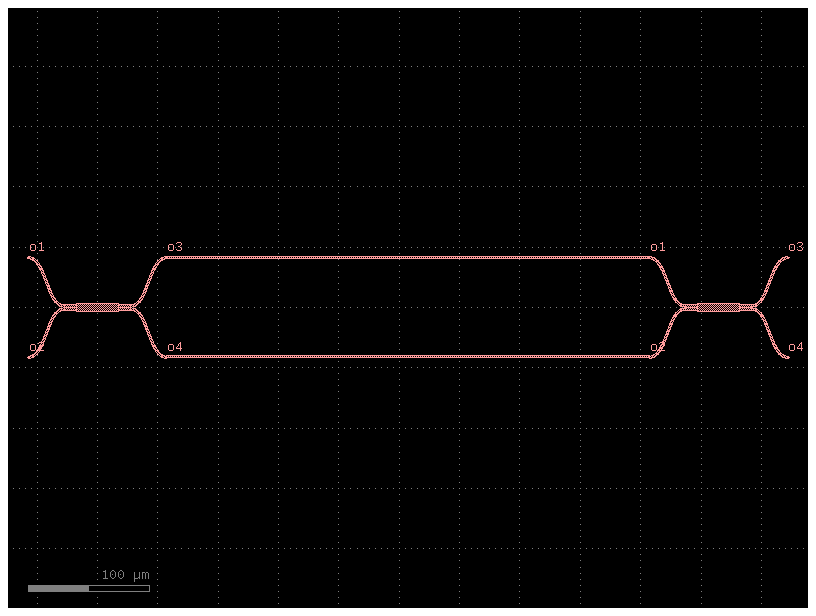

In [24]:
gf.clear_cache()

@gf.cell
def mzi(
    delta_length= 100.0, 
    L_brazo=400.0,
): 
    c  = gf.Component()
    xs = gf.cross_section.strip(width=1.8, layer="WG")

    # MMI izquierdo
    MMI_izq = c.add_ref(mmi2x2_bend())

    # Brazos del MZI
    # El brazo superior lleva la longitud extra (delta_length)
    # El brazo inferior es la referencia
    brazo_sup = c.add_ref(gf.components.straight(length=L_brazo, cross_section=xs)) #length=L_brazo + delta_length
    brazo_inf = c.add_ref(gf.components.straight(length=L_brazo, cross_section=xs))

    # Conectar brazos a las salidas del MMI
    brazo_sup.connect("o1", MMI_izq.ports["o3"])  # Sale por o3 (superior der)
    brazo_inf.connect("o1", MMI_izq.ports["o4"])  # Sale por o4 (inferior der)
    
    # MMI derecho
    MMI_der = c.add_ref(mmi2x2_bend())
    MMI_der.connect("o2", brazo_inf.ports["o2"])  # o2 recibe brazo inferior
    
    
    # Puertos MZI
    c.add_port(name="o1", port=MMI_izq.ports["o1"])   # Entrada inferior izq
    c.add_port(name="o2", port=MMI_izq.ports["o2"])   # Entrada superior izq
    c.add_port(name="o3", port=MMI_der.ports["o3"])   # Salida superior der
    c.add_port(name="o4", port=MMI_der.ports["o4"])   # Salida inferior der

    c.draw_ports()
    return c

# 2. We instantiate references of each cell. We can also name it individually to avoid problems
chip_MZI = gf.Component()

mmi1 = chip_MZI.add_ref(mzi())

chip_MZI.plot()


Desbalanceado (automatico)

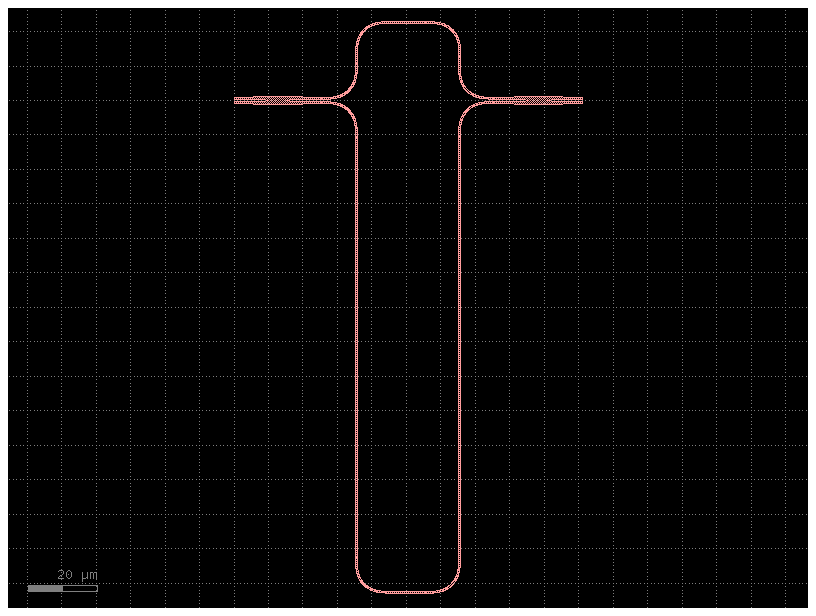

In [25]:
import gdsfactory as gf

@gf.cell
def mzi_unbalanced_2x2(delta_length=0.0):
    c = gf.Component()
    
    mzi_ref = c.add_ref(gf.components.mzi2x2_2x2(
        delta_length=delta_length,
        cross_section='strip'
    ))
    c.add_ports(mzi_ref.ports)
    
    return c

# Lo probamos
mi_mzi_cell = mzi_unbalanced_2x2(delta_length=240)
mi_mzi_cell.plot()

## 3. Complete Layout

2026-06-11 00:05:42.932 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


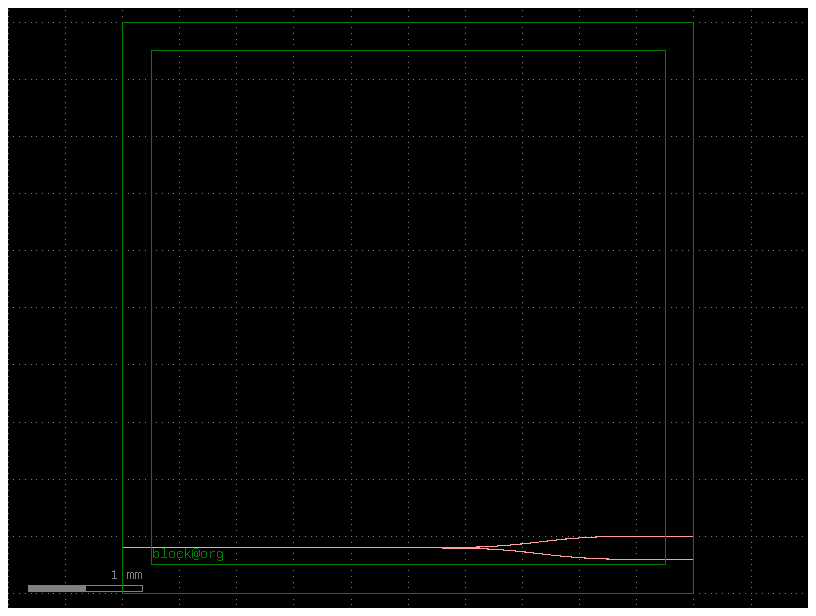

In [21]:
layer_wg  = "WG"
minrad = 50
dieW = 5000

main = gf.Component()

die_ref = main.add_ref(die(dieW = dieW, layer_box="FLOORPLAN"))

## Add first a test MMI routed from side to side
c_mmi = cells.mmi1x2()
mmi = main.add_ref(c_mmi)
mmi.dmovex(die_ref["block@org"].dx + 0.5*dieW).dmovey(die_ref['block@org'].dy + 150)

## Route waveguides from MMI to the die edges
xs = 'strip'
### First add the i/o waveguides - to be sure you 'cut' on a straight section
strin = (main.add_ref(gf.components.straight(length=500, cross_section='strip')).dmovex(0).dmovey(mmi['o1'].dy))
strout1 = (main.add_ref(gf.components.straight(length=500, cross_section=xs)).drotate(180).dmovey(mmi.ports['o3'].dy-100).dmovex(dieW))
strout2 = (main.add_ref(gf.components.straight(length=500, cross_section=xs)).drotate(180).dmovey(mmi.ports['o2'].dy+100).dmovex(dieW))
### Then route from the i/o waveguides to the MMI
gf.routing.route_single_sbend(main,port1=strin['o2'], port2=mmi['o1'], cross_section=xs)
gf.routing.route_single_sbend(main,port1=mmi['o2'], port2=strout2['o2'], cross_section=xs)
gf.routing.route_single_sbend(main,port1=mmi['o3'], port2=strout1['o2'], cross_section=xs)

main.plot()
main.show()

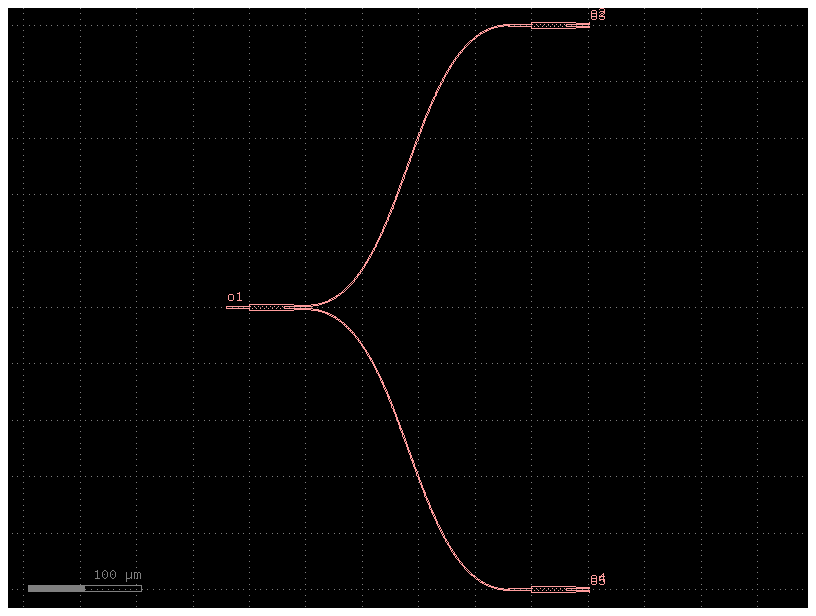

In [22]:
# Let's create a MMI tree

c = gf.Component()
c_mmi = cells.mmi1x2()

mmi1 = c.add_ref(c_mmi)
mmi2 = c.add_ref(c_mmi)
mmi3 = c.add_ref(c_mmi)

mmi2.dmovex(250).dmovey(250)
mmi3.dmovex(250).dmovey(-250)

gf.routing.route_single_sbend(component=c, port1= mmi1['o2'], port2=mmi2['o1'],cross_section='strip')
gf.routing.route_single_sbend(component=c, port1= mmi1['o3'], port2=mmi3['o1'],cross_section='strip')
c.add_port(name='o1', port=mmi1['o1'])
c.add_port(name='o2', port=mmi2['o2'])
c.add_port(name='o3', port=mmi2['o3'])
c.add_port(name='o4', port=mmi3['o2'])
c.add_port(name='o5', port=mmi3['o3'])
c.draw_ports()
c.plot()

In [23]:
# Once we "test" the high-level component, we can create a cell for it
@gf.cell 
def mmi_tree_1x4(pad_x = 250 ,pad_y = 250):
    c = gf.Component()
    c_mmi = cells.mmi1x2()
    mmi1 = c.add_ref(c_mmi)
    mmi2 = c.add_ref(c_mmi)
    mmi3 = c.add_ref(c_mmi)

    mmi2.dmovex(pad_x).dmovey(pad_y)
    mmi3.dmovex(pad_x).dmovey(-pad_y)

    gf.routing.route_single_sbend(component=c, port1= mmi1['o2'], port2=mmi2['o1'],cross_section='strip')
    gf.routing.route_single_sbend(component=c, port1= mmi1['o3'], port2=mmi3['o1'],cross_section='strip')
    c.add_port(name='o1', port=mmi1['o1'])
    c.add_port(name='o2', port=mmi2['o2'])
    c.add_port(name='o3', port=mmi2['o3'])
    c.add_port(name='o4', port=mmi3['o2'])
    c.add_port(name='o5', port=mmi3['o3'])
    c.draw_ports()
    return c

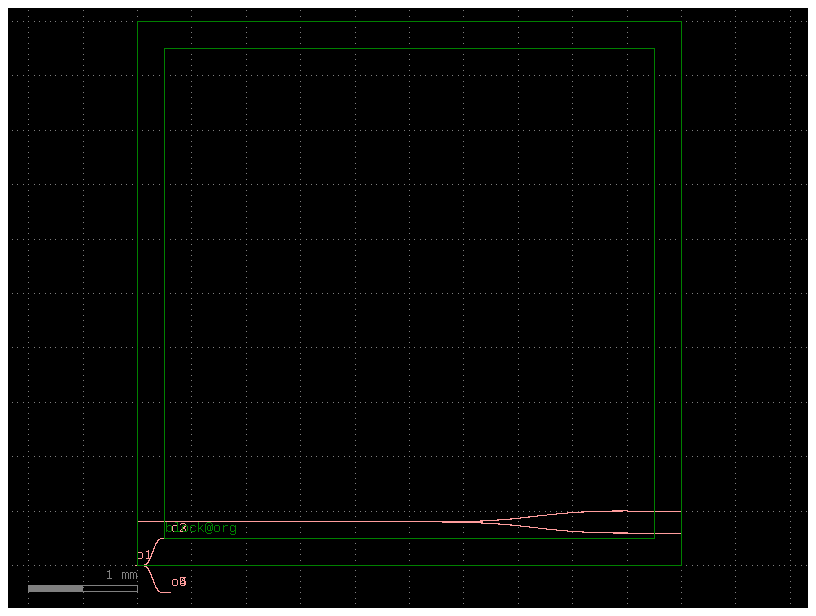

In [24]:
# With the cell created, we can instantiate and use it in our main component
cell_1x4 = main.add_ref(mmi_tree_1x4())
main.plot()


2026-06-11 00:05:58.112 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


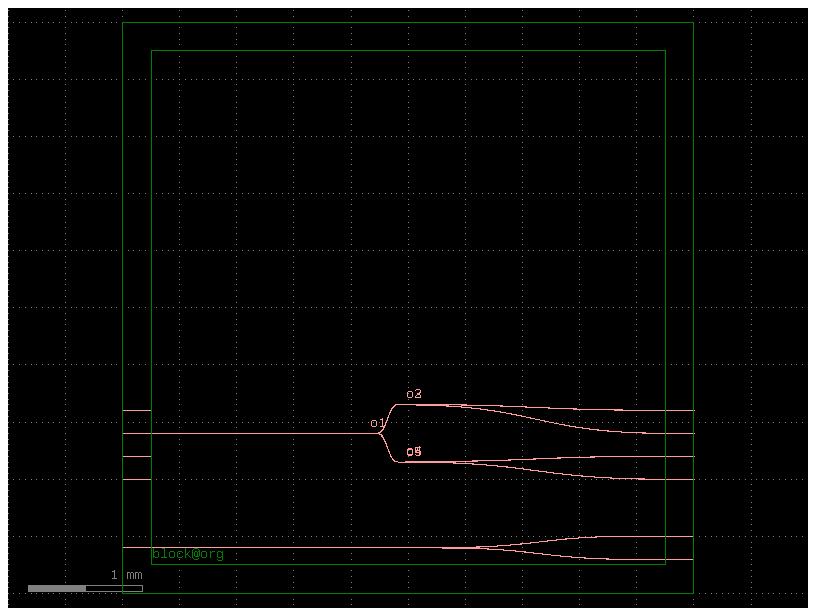

In [25]:
## Arrayed waveguides and MMI tree

sp = 200
border = 250

in_arr = main.add_ref(
    gf.components.straight_array(n=4, spacing=sp, length=border, cross_section=xs)
).dmovey(
    1000
)  #!!!!!! Easy to put IO Waveguides for a complete design !!!!

out_arr = (
    main.add_ref(
        gf.components.straight_array(n=4, spacing=sp, length=border, cross_section=xs)
    )
    .dmovex(dieW - border)
    .dmovey(1000)
)

cell_1x4.dmovex(0.5*dieW - mmi_tree_1x4().dxsize).dmovey(in_arr['o6'].dy)
gf.routing.route_single_sbend(component=main, port1=in_arr['o6'], port2=cell_1x4['o1'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o2'], port2=out_arr['o4'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o3'], port2=out_arr['o3'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o4'], port2=out_arr['o2'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o5'], port2=out_arr['o1'])
main.plot()
main.show()

### Mantra:
It's useful to use memorize this mantra: 
- Add_references 
- Connect_them
- Move_them

### Other Routing options examples:

Please check the GDSFactory Routing API for more information about advanced routing functionalities

[Routing API](https://gdsfactory.github.io/gdsfactory/api_routing.html) 

## 4. Exercises. 

Part a) Creating components
- Create a cell component for a unbalanced MZI, using 2x2 50:50 MMIs with arm length difference as parameter
- Create a cell component based on the previous, where the arms have thermal tuners on top of each one
- Create a cell component for an all-pass ring resonator, using 2x2 50:50 MMIs, with extra length parameter for different perimeters
- Create a cell component based on the previous, where the ring has a thermal tuner on top along all the perimeter
- Create a cell component based on existing GDSfactory spiral components, with length as parameter

Part b) Creating die
- Create a die  W = 5 mm x L = 10 mm 
- Create an array of I/Os spaced at 250 µm (as much I/Os as the width allows)
- Create a cell component of this die, with I/Os accessible to connect

Part c) Floorplaning and die layout
- Make an instance of the die as host component for your layout
- Add 3 sets of 3 straight waveguides, from left to right of the die, top, middle and bottom of the die
- Add 2 of each of the components above, with different lengths
- Connect all your components to the I/Os 

1. Create a cell component for a unbalanced MZI, using 2x2 50:50 MMIs with arm length difference as parameter

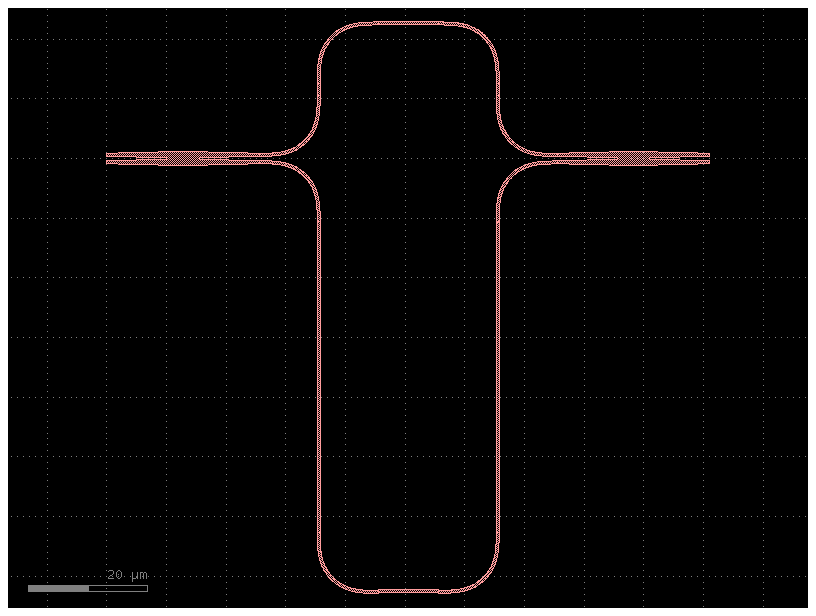

In [32]:
import gdsfactory as gf

@gf.cell
def mzi_unbalanced_2x2(delta_length=0.0):
    c = gf.Component()
    
    mzi_ref = c.add_ref(gf.components.mzi2x2_2x2(
        delta_length=delta_length,
        cross_section='strip'
    ))
    c.add_ports(mzi_ref.ports)
    
    return c

# Lo probamos
mi_mzi_cell = mzi_unbalanced_2x2(delta_length=100)
mi_mzi_cell.plot()

2. Create a cell component based on the previous, where the arms have thermal tuners on top of each one


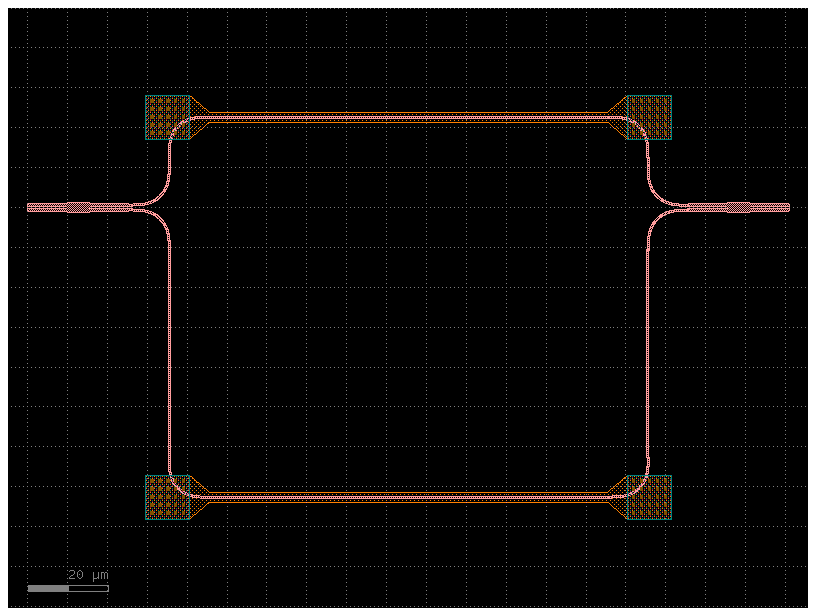

In [33]:
import gdsfactory as gf

@gf.cell
def mzi_heater(
    delta_length=100,
    length_x=100,
):

    c = gf.Component()

    mzi = c.add_ref(
        gf.components.mzi2x2_2x2(
            delta_length=delta_length,
            length_x=length_x,
            straight_x_top='straight_heater_metal',
            straight_x_bot='straight_heater_metal',
            cross_section="strip",
        )
    )
    c.add_ports(mzi.ports)

    return c
mzi_heatercell = mzi_heater(delta_length=100,length_x=100)
mzi_heatercell.plot()

3. Create a cell component for an all-pass ring resonator, using 2x2 50:50 MMIs, with extra length parameter for different perimeters

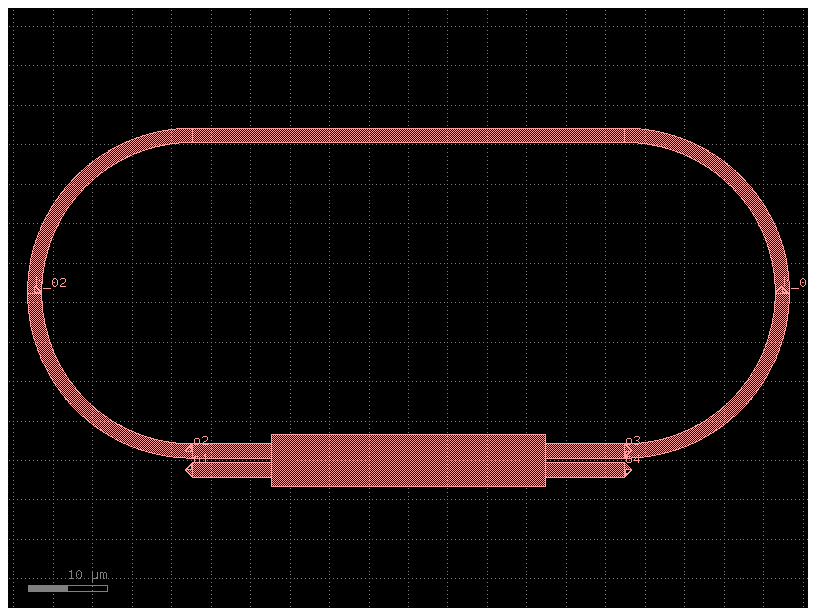

In [83]:
chip_ring_resonator = gf.Component()

mmi1 = chip_ring_resonator.add_ref(ring_resonator(radio   = 20.0))

chip_ring_resonator.plot()

4. Create a cell component based on the previous, where the ring has a thermal tuner on top along all the perimeter

In [7]:
gf.clear_cache()

@gf.cell
def ring_resonator_f(
    W_MMI   = 6.6,
    L_MMI   = 34.718,
    W_wg    = 1.8,
    L_wg    = 10.0,
    dy      = 0.1,
    radio   = 50.0,
    L_extra = 0.0,
):
    c  = gf.Component()
    xs = gf.cross_section.strip(width=W_wg, layer="WG")

    # MMI central
    mmi = c.add_ref(mmi2x2(W_MMI=W_MMI, L_MMI=L_MMI, W_wg=W_wg, L_wg=L_wg, dy=dy))

    # Lado derecho: un solo semicírculo de 180°
    bend_der = c.add_ref(gf.components.bend_circular_heater(angle=180, radius=radio, cross_section=xs))
    bend_der.connect("o1", mmi.ports["o3"])

    # Lado izquierdo: un solo semicírculo de -180°
    bend_izq = c.add_ref(gf.components.bend_circular_heater(angle=-180, radius=radio, cross_section=xs))
    bend_izq.connect("o1", mmi.ports["o2"])

    # Separación entre puertos o2 y o3 del MMI
    sep_puertos = abs(mmi.ports["o2"].dy - mmi.ports["o3"].dy)

    # Recto superior que une ambos semicírculos
    recto = c.add_ref(gf.components.straight_heater_metal(length=50))
    recto.connect("o1", bend_der.ports["o2"],allow_width_mismatch=True, allow_layer_mismatch=True)

    # Conectar el recto con el lado izquierdo
    gf.routing.route_single(
        component=c,
        port1=recto.ports["o2"],
        port2=bend_izq.ports["o2"],
        cross_section=xs
    )

    # Puertos externos (MMI)
    c.add_port(name="o1", port=mmi.ports["o1"])
    c.add_port(name="o2", port=mmi.ports["o2"])
    c.add_port(name="o3", port=mmi.ports["o3"])
    c.add_port(name="o4", port=mmi.ports["o4"])

    c.draw_ports()
    return c

chip_ring_resonator = gf.Component()
mmi1 = chip_ring_resonator.add_ref(ring_resonator_f())
chip_ring_resonator.plot()

NameError: name 'mmi2x2' is not defined

In [8]:
gf.clear_cache()

@gf.cell
def ring_resonator_f(
    W_MMI    = 6.6,
    L_MMI    = 34.718,
    W_wg     = 1.8,
    L_wg     = 10.0,
    dy       = 0.1,
    radio    = 50.0,
    L_extra  = 0.0,
    W_heater = 2.5,
):
    c = gf.Component()

    # ── Cross-section con WG + HEATER superpuestos ────────────────────
    xs_wg_ht = gf.cross_section.strip(
        width=W_wg,
        layer="WG",
        sections=[
            gf.Section(width=W_heater, layer="HEATER", name="heater")
        ]
    )

    xs = gf.cross_section.strip(width=W_wg, layer="WG")  # solo WG para MMI ports

    # ── MMI central ───────────────────────────────────────────────────
    mmi = c.add_ref(mmi2x2(W_MMI=W_MMI, L_MMI=L_MMI,
                            W_wg=W_wg,   L_wg=L_wg, dy=dy))

    # ── Semicírculo derecho: WG + HEATER ──────────────────────────────
    bend_der = c.add_ref(gf.components.bend_circular(
                    angle=180, radius=radio, cross_section=xs_wg_ht))
    bend_der.connect("o1", mmi.ports["o3"],
                     allow_width_mismatch=True, allow_layer_mismatch=True)

    # ── Semicírculo izquierdo: WG + HEATER ────────────────────────────
    bend_izq = c.add_ref(gf.components.bend_circular(
                    angle=-180, radius=radio, cross_section=xs_wg_ht))
    bend_izq.connect("o1", mmi.ports["o2"],
                     allow_width_mismatch=True, allow_layer_mismatch=True)

    sep_puertos = abs(mmi.ports["o2"].dy - mmi.ports["o3"].dy)

    # ── Recto superior: WG + HEATER ───────────────────────────────────
    recto = c.add_ref(gf.components.straight(
                    length=sep_puertos, cross_section=xs_wg_ht))
    recto.connect("o1", bend_der.ports["o2"],
                  allow_width_mismatch=True, allow_layer_mismatch=True)

    # ── Cierre del anillo ─────────────────────────────────────────────
    gf.routing.route_single(
        component=c,
        port1=recto.ports["o2"],
        port2=bend_izq.ports["o2"],
        cross_section=xs_wg_ht,
    )

    # ── Puertos externos ──────────────────────────────────────────────
    c.add_port(name="o1", port=mmi.ports["o1"])
    c.add_port(name="o2", port=mmi.ports["o2"])
    c.add_port(name="o3", port=mmi.ports["o3"])
    c.add_port(name="o4", port=mmi.ports["o4"])
    c.add_port(name="h_02", port=bend_izq.ports["o2"])
    c.add_port(name="h_03", port=bend_der.ports["o2"])

    c.draw_ports()
    return c

chip_ring_resonator = gf.Component()
mmi1 = chip_ring_resonator.add_ref(ring_resonator_f())
chip_ring_resonator.plot()

NameError: name 'mmi2x2' is not defined

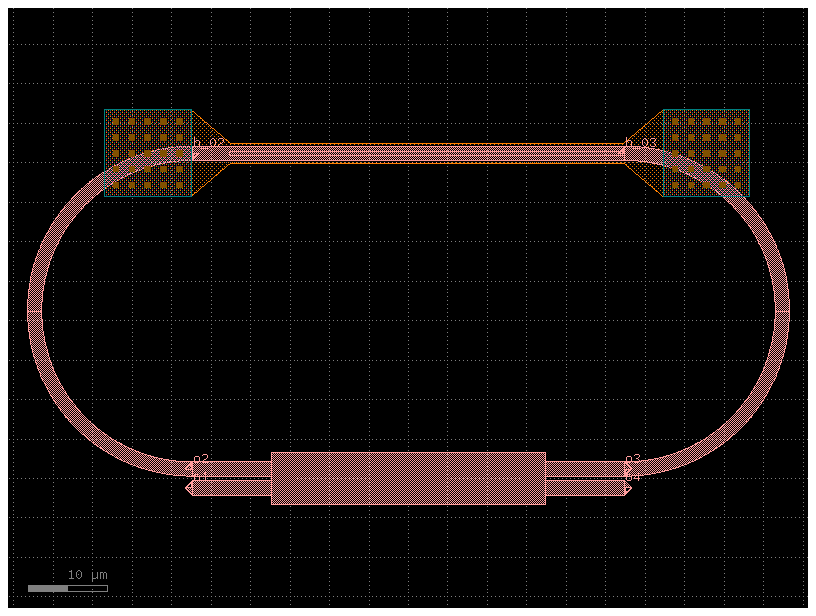

In [252]:
@gf.cell
def ring_lheater(radio=20.0):
    c = gf.Component()
    
    ring = c.add_ref(ring_resonator(radio=radio))
    
    # Separación entre puertos de heater
    
    # Recto del heater conectado directamente por ambos extremos
    recto_h = c.add_ref(gf.components.straight_heater_metal(length=50, cross_section=xs))
    recto_h.connect("o1", ring.ports["h_03"],
        allow_width_mismatch=True, allow_layer_mismatch=True)

    gf.routing.route_single(component=c,port1=recto_h.ports["o2"],port2=ring.ports["h_02"],cross_section=xs)

    # Puertos externos
    c.add_port(name="o1", port=ring.ports["o1"])
    c.add_port(name="o2", port=ring.ports["o2"])
    c.draw_ports()
    return c

heatercell_p = ring_lheater()
heatercell_p.plot()

5.Create a cell component based on existing GDSfactory spiral components, with length as parameter

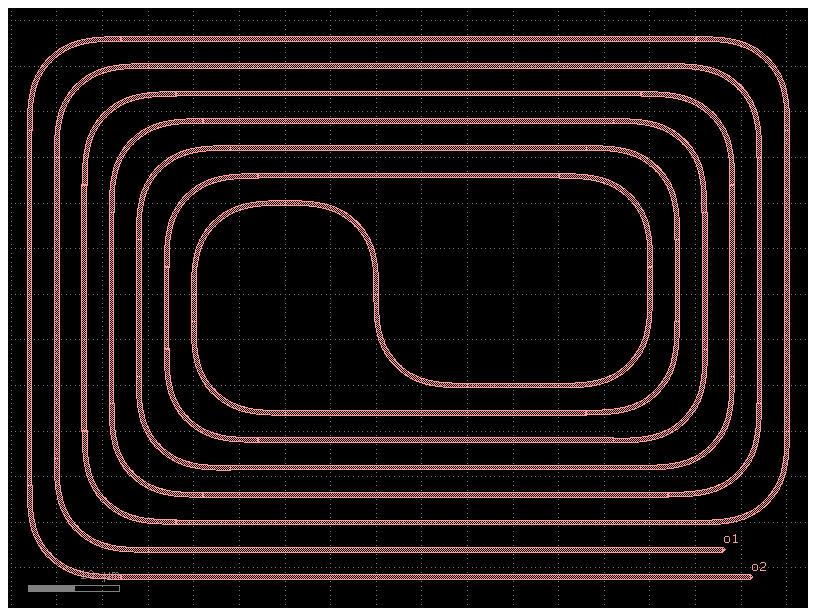

In [275]:
def spiral():
    c = gf.components.spiral(length=10, cross_section="strip")
    c.draw_ports()
    return c

c = spiral()
c.plot()


Creating die
- Create a die  W = 5 mm x L = 10 mm 
- Create an array of I/Os spaced at 250 µm (as much I/Os as the width allows)
- Create a cell component of this die, with I/Os accessible to connect


2026-06-11 00:55:58.545 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


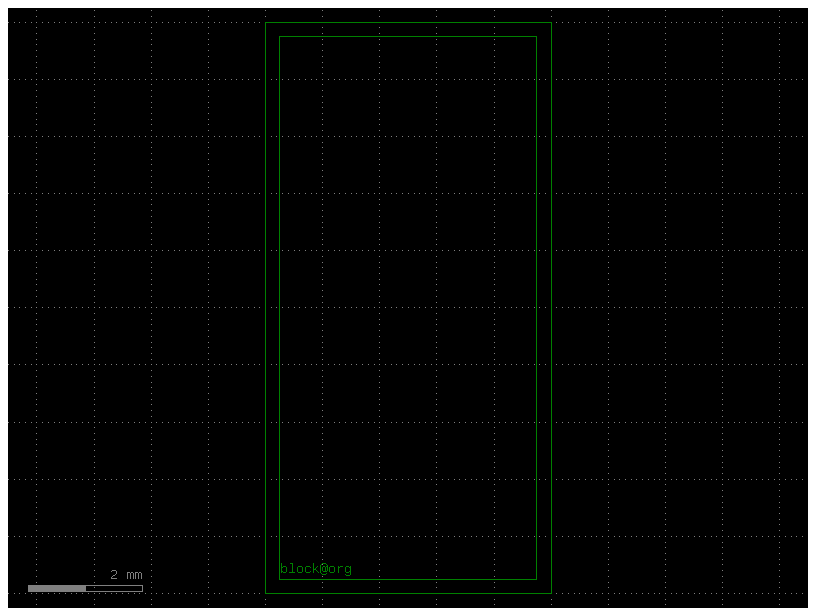

In [115]:
gf.clear_cache()

@gf.cell
def die_WL(dieL = 10000, dieW = 5000, border = 250, layer_box = "FLOORPLAN"):
    # Die specifications (Chip)
    box = gf.Component()
    obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
    ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
    box = gf.boolean(A=obox, B=ibox, operation="A-B", layer=layer_box)
    # Adding ports to a component 
    box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)
    box.draw_ports()
    
    return box

# 2. We instantiate references of each cell. We can also name it individually to avoid problems
wafer = gf.Component()
dieW = 5000

c1 = wafer.add_ref(die_WL(dieW = dieW))

wafer.show()
wafer.plot()


2026-06-11 00:56:00.369 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


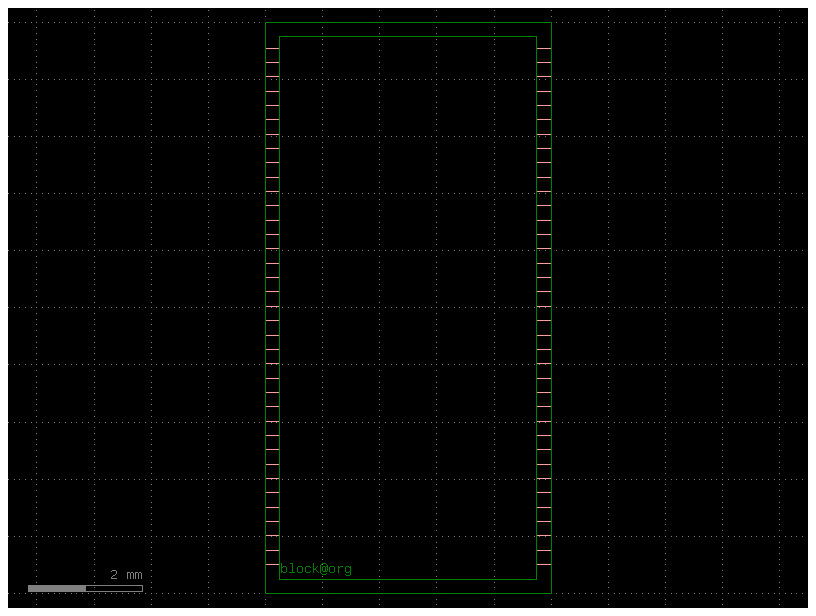

In [116]:
## Arrayed waveguides 

sp = 250
border = 250

in_arr = wafer.add_ref(
    gf.components.straight_array(n=37, spacing=sp, length=border, cross_section=xs)
).dmovey(
    500
) 

out_arr = (
    wafer.add_ref(
        gf.components.straight_array(n=37, spacing=sp, length=border, cross_section=xs)
    )
    .dmovex(dieW - border)
    .dmovey(500)
)

wafer.plot()
wafer.show()

Floorplaning and die layout
- Make an instance of the die as host component for your layout
- Add 3 sets of 3 straight waveguides, from left to right of the die, top, middle and bottom of the die
- Add 2 of each of the components above, with different lengths
- Connect all your components to the I/Os 

2026-06-11 00:56:55.577 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


ValueError: Ports need to have orthogonal orientation 180.0
port1 = 180.0 deg and port2 = 180.0

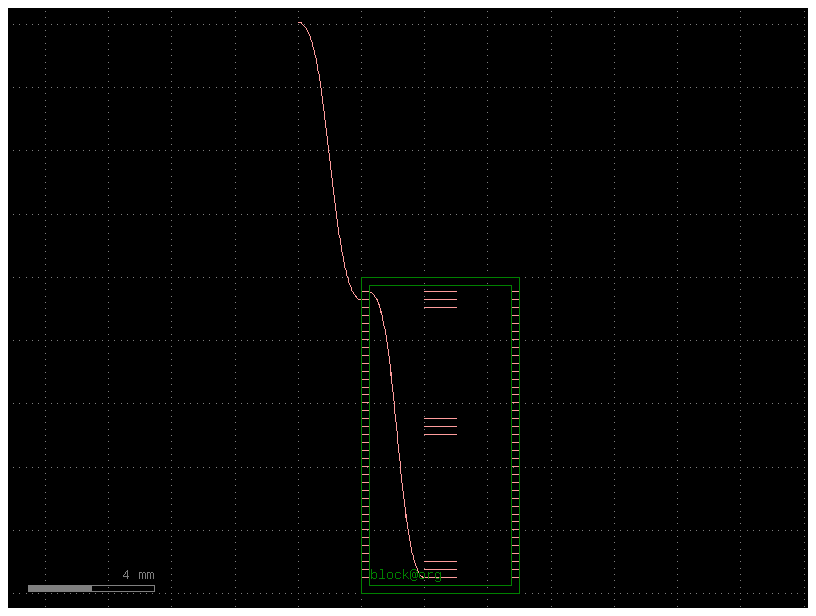

In [121]:
#wafer = gf.Component()

#die_l = wafer.add_ref(die_WL())

rows = {
    "bottom": [0, 1, 2],      # filas 0,1,2 del array
    "middle": [18, 19, 20],   # filas 18,19,20 del array
    "top"   : [34, 35, 36],   # filas 35,36,37 del array
}
wg_refs = {}
for set_name, row_list in rows.items():
    for row_idx in row_list:
        ref_name = f"wg_{set_name}_{row_idx}"
        wg = wafer.add_ref(gf.components.straight(length=1000, cross_section=xs))
        wg.dmovex(0.5*5000-500).dmovey(in_arr[f'o{row_idx+1}'].dy)
        wg_refs[ref_name] = (wg, row_idx)

wafer.plot()
wafer.show()

for ref_name, (wg, row_idx) in wg_refs.items():
    port_num = row_idx + 1  
    gf.routing.route_single_sbend(component=wafer, port1=in_arr[f'o{port_num}'], port2=wg['o1'],cross_section = xs)
    gf.routing.route_single_sbend(component=wafer, port1=wg['o2'], port2=out_arr[f'o{port_num}'],cross_section = xs)

wafer.plot()
wafer.show()
